# DengAI · 3. Preprocessing and feature engineering

This notebook turns the raw weekly table into model inputs. Every
transformation is motivated by a finding from notebook 02.

1. Categorical and date columns
2. Missing values
3. Target variable
4. Feature set A: tabular features for the tree models
5. Feature set B: raw climate histories (lag windows)
6. Feature set C: **multiscale climate summaries**, the final representation
7. Scaling and the train / predict alignment

The code lives in the `dengai` package (`dengai/features.py`); the
notebook calls it step by step and shows the intermediate results.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "dengai").is_dir())
sys.path.insert(0, str(ROOT))
OUTPUT_DIR = ROOT / "notebooks" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from dengai import features as F
from dengai.config import (CITY_NAMES, DATE_COLUMN, LAG_WINDOWS, SUMMARY_NAMES, TARGET_COLUMN,
                           WEATHER_FEATURES)
from dengai.data import city_frame, find_data_dir, interpolate_climate, load_data
from dengai.plotting import CITY_COLORS, MUTED, SERIES, set_style

set_style()
train, test, template = load_data(find_data_dir(ROOT))

## 1. Categorical and date columns

| Column | Type | Encoding | Motivation |
|---|---|---|---|
| `city` | categorical (2 levels) | **one model per city** instead of a one-hot column | cases differ ~5× in scale and the climate regimes differ (EDA §2, §10); separate models let each city learn its own climate–dengue relationship and hyper-parameters |
| `week_start_date` | date | used only to sort rows and build folds | a raw timestamp would let a model memorise specific years, which never recur in the test period |
| `year` | integer | kept as a numeric trend input only for the trees | lets trees capture slow drifts in reporting; not used by the MLP |
| `weekofyear` | cyclic integer 1–53 | **sin / cos harmonics** | week 52 and week 1 are adjacent in time but far apart as integers (EDA §3) |

The harmonic encoding maps each week onto a circle:

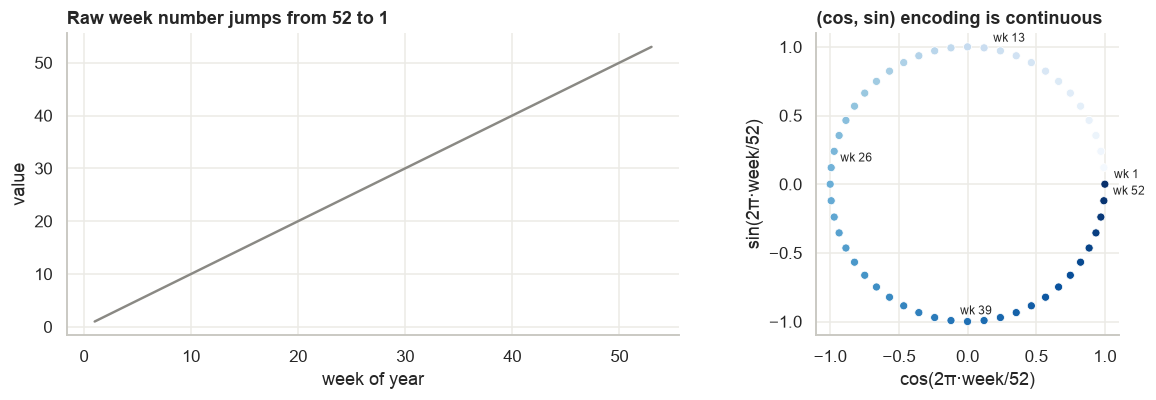

In [2]:
weeks = np.arange(1, 54)
phase = 2 * np.pi * (weeks - 1) / 52
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), gridspec_kw={"width_ratios": [1.6, 1]})
axes[0].plot(weeks, weeks, color=MUTED, label="raw week number")
axes[0].set(title="Raw week number jumps from 52 to 1", xlabel="week of year", ylabel="value")
axes[1].scatter(np.cos(phase), np.sin(phase), c=weeks, cmap="Blues", s=28, edgecolor="white", linewidth=0.5)
for w in (1, 13, 26, 39, 52):
    axes[1].annotate(f"wk {w}", (np.cos(phase[w - 1]), np.sin(phase[w - 1])), xytext=(6, 4), textcoords="offset points", fontsize=8)
axes[1].set(title="(cos, sin) encoding is continuous", xlabel="cos(2π·week/52)", ylabel="sin(2π·week/52)", aspect="equal")
plt.tight_layout()

We use the annual and the semi-annual harmonic (`sin/cos(2·phase)`) so the
model can also represent an asymmetric season (slow rise, fast fall).
The tree features use four harmonics.

## 2. Missing values

In [3]:
weather = [c for c in train.columns if c not in ("city", "year", "weekofyear", DATE_COLUMN, TARGET_COLUMN)]
pd.DataFrame({
    f"{split} {CITY_NAMES[c]}": frame.loc[frame["city"].eq(c), weather].isna().sum()
    for split, frame in [("train", train), ("test", test)] for c in CITY_NAMES
}).loc[lambda d: d.sum(axis=1) > 0].sort_values("train San Juan", ascending=False).head(8)

,train San Juan,train Iquitos,test San Juan,test Iquitos
ndvi_ne,191,3,43,0
ndvi_nw,49,3,11,0
ndvi_se,19,3,1,0
ndvi_sw,19,3,1,0
reanalysis_sat_precip_amt_mm,9,4,2,0
precipitation_amt_mm,9,4,2,0
station_min_temp_c,6,8,2,7
station_max_temp_c,6,14,2,1


Two strategies, one per model family, each fitted without seeing
validation targets:

* **Neural network: linear interpolation along time, per city.** Climate
  varies smoothly and gaps are at most 6 weeks long (EDA §5), so a
  straight line between the neighbouring observations is a good estimate.
  The history features need a complete series; a single NaN would
  corrupt every rolling statistic that touches it. The test file is
  interpolated on its own.
* **Trees: median imputation inside the model pipeline.** The NaNs are kept
  while lags are computed and then replaced by the *training-fold* median
  (`SimpleImputer` in a scikit-learn `Pipeline`), so validation rows never
  influence the fill value.

An example of a gap before and after interpolation:

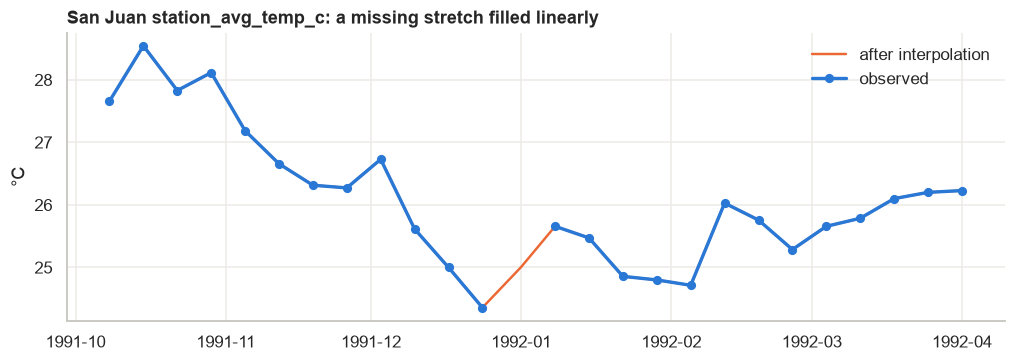

In [4]:
sj = city_frame(train, "sj")
column = "station_avg_temp_c"
gap_rows = np.flatnonzero(sj[column].isna())
center = gap_rows[np.argmax(np.diff(np.r_[gap_rows, gap_rows[-1]]) == 1)]
window = sj.iloc[center - 12 : center + 14]
filled = interpolate_climate(window)

fig, ax = plt.subplots(figsize=(11, 3.4))
ax.plot(filled[DATE_COLUMN], filled[column], color=SERIES[1], lw=1.6, label="after interpolation")
ax.plot(window[DATE_COLUMN], window[column], color=SERIES[0], lw=2.2, marker="o", ms=5, label="observed")
ax.set(title=f"San Juan {column}: a missing stretch filled linearly", ylabel="°C", xlabel="")
ax.legend();

## 3. Target variable

`total_cases` is already the quantity we want, so no relabelling is
needed. The skew and overdispersion (EDA §2) are handled inside each
model rather than by changing the target for every model:

| Model | Target handling | Why |
|---|---|---|
| MLP (final) | raw counts, **MAE loss** | minimising MAE estimates the conditional *median*, robust to outbreak spikes and identical to the evaluation metric |
| Iquitos Random Forest | `log1p(cases)`, back-transformed with `expm1` | compresses rare spikes in a small, zero-heavy series |
| San Juan Extra Trees | raw counts, **Poisson** split criterion | treats the target as a count whose variance grows with its level |

Predictions are clipped at 0 and converted to integers for the submission.

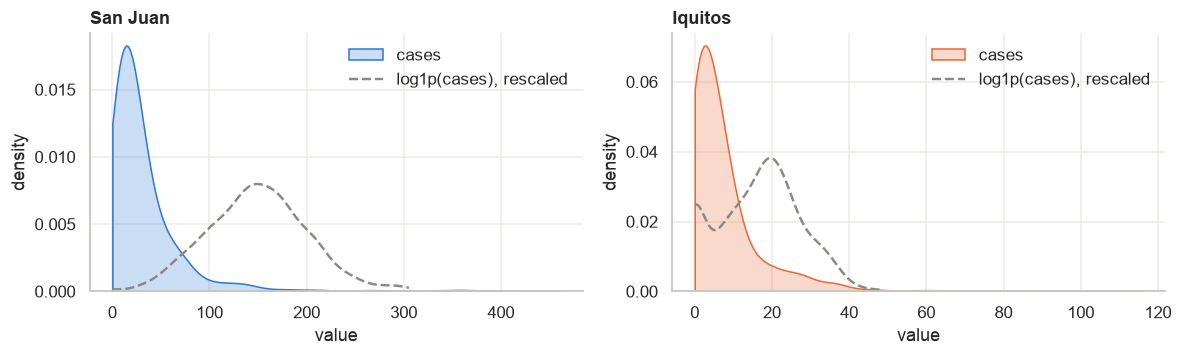

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for ax, (city, name) in zip(axes, CITY_NAMES.items()):
    y = train.loc[train["city"].eq(city), TARGET_COLUMN]
    sns.kdeplot(y, ax=ax, color=CITY_COLORS[city], fill=True, label="cases", cut=0)
    sns.kdeplot(np.log1p(y) * y.std() / np.log1p(y).std(), ax=ax, color=MUTED, ls="--", label="log1p(cases), rescaled", cut=0)
    ax.set(title=name, xlabel="value", ylabel="density")
    ax.legend()
plt.tight_layout()

## 4. Feature set A: tabular features for the tree ensembles

For every week, `tree_features` builds:

* the 20 current climate measurements, `year`, `weekofyear`, and 4 sin/cos harmonic pairs;
* NDVI mean and spread across the four satellite pixels;
* station and reanalysis daily temperature ranges, and a temperature × humidity interaction;
* for 9 humidity, temperature and rainfall variables: **lags 1, 2, 4, 8, 12, 16 weeks** and
  **trailing means over 2–16 weeks**.

The trailing means use `shift(1)`, so the current week never enters its
own "past" average. Case counts are never used as features (EDA §9).

In [6]:
tree_x = F.tree_features(city_frame(train, "sj"))
groups = pd.Series(
    np.select(
        [tree_x.columns.str.contains("__lag_"), tree_x.columns.str.contains("__past_mean_"),
         tree_x.columns.str.startswith("week_")],
        ["climate lags", "trailing climate means", "seasonal harmonics"],
        "current climate / derived",
    )
).value_counts()
print("tree feature matrix:", tree_x.shape)
groups

tree feature matrix: (936, 134)


climate lags                 54
trailing climate means       45
current climate / derived    27
seasonal harmonics            8
Name: count, dtype: int64

In [7]:
example = tree_x[["station_precip_mm", "station_precip_mm__lag_1", "station_precip_mm__lag_2",
                  "station_precip_mm__past_mean_2", "station_precip_mm__past_mean_4"]].iloc[14:20]
example.round(1)

,station_precip_mm,station_precip_mm__lag_1,station_precip_mm__lag_2,station_precip_mm__past_mean_2,station_precip_mm__past_mean_4
14,11.4,37.6,32.6,35.1,36.5
15,44.7,11.4,37.6,24.5,23.5
16,5.4,44.7,11.4,28.0,31.6
17,13.7,5.4,44.7,25.0,24.8
18,14.2,13.7,5.4,9.6,18.8
19,25.9,14.2,13.7,14.0,19.5


Each `lag_k` column is the observed value shifted down `k` rows;
`past_mean_2` at row *t* is the mean of rows *t−1* and *t−2*. The
unit test `tests/test_dengai_package.py::test_tree_features_are_past_only`
changes future weeks and checks that past features stay identical.

## 5. Feature set B: raw climate histories

The tree features sample history at a few fixed lags. A richer
alternative gives the model each variable's **entire recent trajectory**.
How many weeks per variable? A per-feature screening (a
`DecisionTreeRegressor` fitted on windows of 3–51 weeks, one variable at
a time) chose a different history length for each variable and city:

inputs per row: {'San Juan': 461, 'Iquitos': 380}


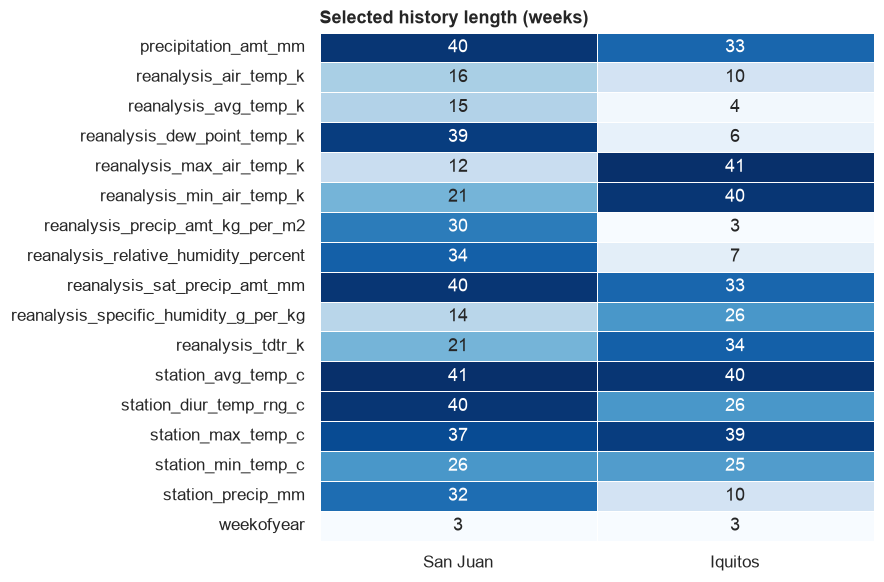

In [8]:
windows = pd.DataFrame(LAG_WINDOWS).rename(columns=CITY_NAMES)
fig, ax = plt.subplots(figsize=(6.5, 6))
sns.heatmap(windows, annot=True, fmt="d", cmap="Blues", cbar=False, linewidths=0.5, ax=ax)
ax.set_title("Selected history length (weeks)")
print("inputs per row:", {CITY_NAMES[c]: sum(w.values()) for c, w in LAG_WINDOWS.items()})

A window of 40 means *all 40 consecutive weeks* `x[t−39], …, x[t]`.
Concatenated, that is **461 inputs for San Juan and 380 for Iquitos**,
for only 936 and 520 labelled weeks. Two weaknesses:

* Many inputs per label, and much of their variation is week-to-week
  weather noise rather than signal (shown in section 6).
* The screening used shuffled 10-fold CV, which is not forecasting-safe,
  so the exact lengths (39 vs 40) carry noise.

## 6. Feature set C: multiscale climate summaries (final)

Instead of copying every week, describe each variable's past 52 weeks by
**what matters biologically**: its level at several timescales, how
variable it was, and whether it is rising or falling.

For each of the 16 climate variables (all *z*-scored):

| # | Summary | Captures |
|---|---|---|
| 1 | current value | this week's conditions |
| 2–7 | mean over the last 2, 4, 8, 13, 26, 52 weeks | short-, medium- and long-term level (EDA §8) |
| 8–9 | standard deviation over 4 and 13 weeks | recent volatility |
| 10 | 4-week mean − 13-week mean | is the last month unusual for the season? |
| 11 | (current − value 12 weeks ago) / 12 | 13-week trend |

plus 4 seasonal harmonics: **16 × 11 + 4 = 180 inputs** for both cities.

In [9]:
cities = {c: interpolate_climate(city_frame(train, c)) for c in CITY_NAMES}
stats = F.normalization_stats(cities["sj"])
x_ms, y_ms = F.training_matrix(cities["sj"], "sj", stats, F.MULTISCALE)
names = F.multiscale_names()
print("multiscale matrix (San Juan):", x_ms.shape)

# Worked example: the satellite-rainfall summaries for one training week.
row = 400  # row order is [n-2, n-1, 0, 1, ...], so row 400 is week 398 of the series
week_date = cities["sj"][DATE_COLUMN].iloc[row - 2].date()
pd.Series(x_ms[row, :11], index=SUMMARY_NAMES, name=f"precipitation_amt_mm, week of {week_date}").round(3).to_frame()

multiscale matrix (San Juan): (936, 180)


,"precipitation_amt_mm, week of 1997-12-24"
current,-0.290
mean_2w,-0.546
mean_4w,-0.656
mean_8w,-0.512
mean_13w,-0.104
mean_26w,-0.058
mean_52w,-0.248
std_4w,0.213
std_13w,0.763
mean4_minus_mean13,-0.552


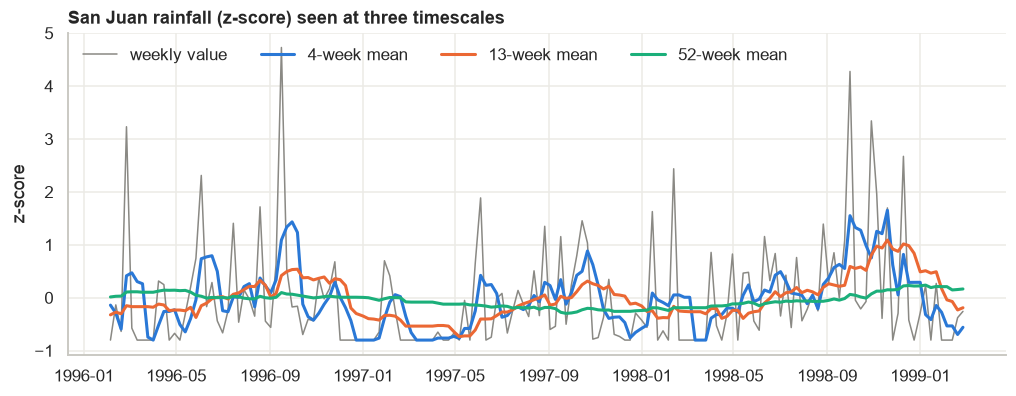

In [10]:
rain = (cities["sj"]["precipitation_amt_mm"] - stats["precipitation_amt_mm"][0]) / stats["precipitation_amt_mm"][1]
dates = cities["sj"][DATE_COLUMN]
span = slice(300, 460)
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(dates[span], rain[span], color=MUTED, lw=1, label="weekly value")
for w, color in zip((4, 13, 52), SERIES[:3]):
    ax.plot(dates[span], rain.rolling(w).mean()[span], color=color, lw=2, label=f"{w}-week mean")
ax.set(title="San Juan rainfall (z-score) seen at three timescales", ylabel="z-score", xlabel="")
ax.legend(ncols=4, loc="upper left");

The weekly series is noisy; the 4-, 13- and 52-week means show the wet
spell, the seasonal cycle and the year-to-year level separately. A
one-week shift of a wet episode moves the rolling means only slightly,
while in the raw representation it moves information to a different input
column. This makes the summaries more stable to learn from.

**What the summaries change.** A useful check is how many principal
components each representation needs to explain most of its variance.
Few components mean the information sits in a few smooth directions;
many mean it is spread over week-to-week fluctuations.

/var/folders/1_/2f5z_t9n5bxdbfgrnw2180s00000gn/T/ipykernel_18782/1946560349.py:12: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  g = sns.relplot(data=pca, x="components", y="cumulative variance", hue="representation", col="City",


components for 95% variance
City     representation                                      
Iquitos  multiscale (180 inputs)                           41
         raw_lags (380 inputs)                            163
San Juan multiscale (180 inputs)                           36
         raw_lags (461 inputs)                            165

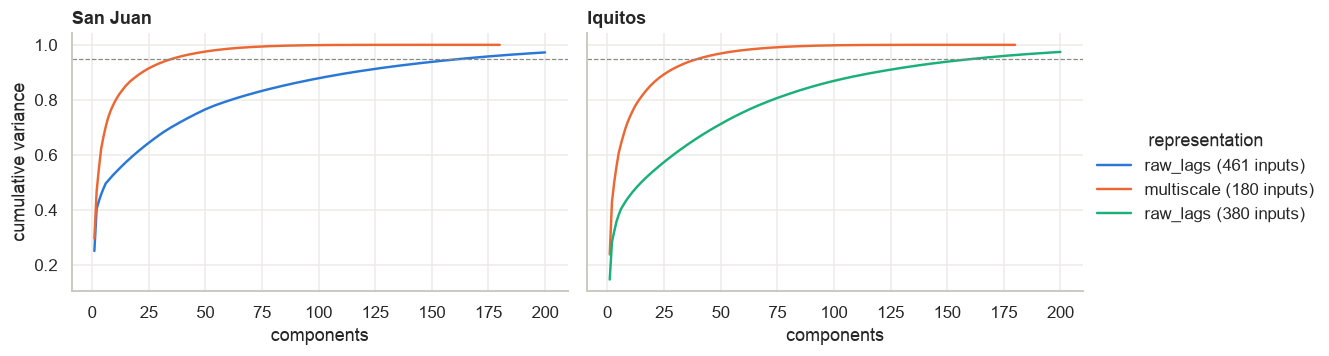

In [11]:
rows = []
for city in CITY_NAMES:
    for representation in (F.RAW_LAGS, F.MULTISCALE):
        x, _ = F.training_matrix(cities[city], city, stats, representation)
        z = (x - x.mean(axis=0)) / (x.std(axis=0) + 1e-12)
        explained = np.linalg.svd(z, compute_uv=False) ** 2
        cumulative = np.cumsum(explained) / explained.sum()
        label = f"{representation} ({x.shape[1]} inputs)"
        rows += [{"City": CITY_NAMES[city], "representation": label, "components": k + 1,
                  "cumulative variance": v} for k, v in enumerate(cumulative[:200])]
pca = pd.DataFrame(rows)
g = sns.relplot(data=pca, x="components", y="cumulative variance", hue="representation", col="City",
                kind="line", height=3.4, aspect=1.5, palette=SERIES[:4], facet_kws={"sharex": True})
for ax in g.axes.flat:
    ax.axhline(0.95, color=MUTED, lw=0.8, ls="--")
g.set_titles("{col_name}")
(pca[pca["cumulative variance"] >= 0.95].groupby(["City", "representation"])["components"].min()
 .rename("components for 95% variance").to_frame())

The raw histories need about **165 components** to reach 95% of their
variance: most of it is week-to-week weather noise, and the network has to
learn to average it away from only 936 or 520 examples. The multiscale
summaries reach 95% with about **40 components**. They work as a
**low-pass filter**: the smooth, slowly varying climate state that EDA §8
linked to cases is computed explicitly, and the noise is not passed on.

The network also has fewer weights to fit: San Juan's first layer
shrinks from 461 × 100 to 180 × 100. Notebook 04 tests whether this
improves forecasts, and whether adding the summaries *on top of* the raw
histories works as well (if it does not, the gain comes from removing
noise, not from adding information).

## 7. Scaling and train / predict alignment

**Scaling.** Neural networks train best when inputs share a scale. Each
climate variable is *z*-scored with the mean and standard deviation of the
**San Juan training weeks**, and the same parameters are applied to
Iquitos ("shared-SJ" scaling). With shared scaling, a value of +1 means the
same physical temperature or rainfall in both cities. It was also the
better option in leaderboard comparisons. Statistics come from the
training rows only (within each CV fold: from the weeks before the
validation year).

In [12]:
pd.DataFrame(stats, index=["mean / min", "std / max"]).T.round(3).head(6)

,mean / min,std / max
precipitation_amt_mm,35.289,44.040
reanalysis_air_temp_k,299.179,1.250
reanalysis_avg_temp_k,299.292,1.234
reanalysis_dew_point_temp_k,295.095,1.570
reanalysis_max_air_temp_k,301.411,1.279
reanalysis_min_air_temp_k,297.308,1.304


**Alignment.** The feature builder pairs each training week with the
climate history that ends at that same week. When forecasting, the
prediction for week *t* uses the history that ends at **week *t − 2***,
a two-week lead. In practice this leaves two weeks for climate data to be
published and for public-health teams to act on the forecast. It is the
alignment of the leaderboard-confirmed submission; notebook 04 measures
its effect against a same-week alignment.

The first 51 training weeks have less than a year of history. Instead of
dropping them, the series is padded with its own last 53 weeks, so those
rows borrow *climate* (never case counts) from the end of the training
period.

In [13]:
test_cities = {c: interpolate_climate(city_frame(test, c)) for c in CITY_NAMES}
shapes = []
for city in CITY_NAMES:
    for representation in F.REPRESENTATIONS:
        x, y = F.training_matrix(cities[city], city, stats, representation)
        x_test = F.prediction_matrix(cities[city], test_cities[city], city, stats, representation)
        shapes.append({"city": CITY_NAMES[city], "representation": representation,
                       "X_train": x.shape, "y_train": y.shape, "X_test": x_test.shape,
                       "finite": bool(np.isfinite(x).all() and np.isfinite(x_test).all())})
pd.DataFrame(shapes)

,city,representation,X_train,y_train,X_test,finite
0,San Juan,raw_lags,"(936, 461)","(936,)","(260, 461)",True
1,San Juan,multiscale,"(936, 180)","(936,)","(260, 180)",True
2,San Juan,raw_plus_multiscale,"(936, 641)","(936,)","(260, 641)",True
3,Iquitos,raw_lags,"(520, 380)","(520,)","(156, 380)",True
4,Iquitos,multiscale,"(520, 180)","(520,)","(156, 180)",True
5,Iquitos,raw_plus_multiscale,"(520, 560)","(520,)","(156, 560)",True


## Summary of transformations

| Step | What | Why (EDA evidence) |
|---|---|---|
| City | separate models | different scales and climates (§2, §10) |
| Week of year | sin/cos harmonics | continuous seasonal cycle (§3) |
| Missing climate | time interpolation (MLP), fold-median imputation (trees) | short gaps in smooth series (§5) |
| Target | MAE loss / log1p / Poisson; clip at 0, integers | skewed, overdispersed counts (§2) |
| Tree features | lags 1–16 and trailing means | delayed climate effects (§7) |
| Raw lag windows | feature-specific contiguous histories (461/380 inputs) | different delays per variable and city (§7) |
| **Multiscale summaries** | 11 summaries × 16 variables + 4 harmonics (180 inputs) | accumulated conditions at several timescales (§8); filter weekly noise, fewer weights |
| Scaling | shared San Juan *z*-scores | stable optimisation; comparable units across cities |
| No case lags | none of the representations use past cases | labels unavailable over the 3–5-year test horizon (§9) |